In [1]:
# Notebooks run from the notebooks folder, so the src folder is added to the path.
import sys
from pathlib import Path

src_folder = Path.cwd().parent / "src"
sys.path.insert(0, str(src_folder))

In [2]:
# Reloads edited modules in src without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [4]:
from prepare import load_chips
from metrics import split_chips, calculate_ndvi, score_prediction, find_best_ndvi_threshold

chips = load_chips()
train_chips, val_chips, test_chips = split_chips(chips)

Training tiles:   1127
Validation tiles: 392
Test tiles:       392


In [5]:
import json

best_threshold = find_best_ndvi_threshold(train_chips)

# The threshold is saved so notebook 04 can apply the same cutoff.
with open(config.NDVI_THRESHOLD_FILE, "w") as threshold_file:
    json.dump({"threshold": float(best_threshold)}, threshold_file)

# The test tiles are flattened in the same manner.
test_ndvi_list = []
test_truth_list = []
test_landcover_list = []

for chip in test_chips:
    ndvi = calculate_ndvi(chip["img"])
    test_ndvi_list.append(ndvi.ravel())
    test_truth_list.append(chip["msk"].ravel())
    test_landcover_list.append(chip["lc8"].ravel())

test_ndvi = np.concatenate(test_ndvi_list)
test_truth = np.concatenate(test_truth_list)
test_landcover = np.concatenate(test_landcover_list)

# The threshold from training is applied without adjustment.
ndvi_prediction = test_ndvi > best_threshold
ndvi_scores = score_prediction(ndvi_prediction, test_truth)

print("NDVI results on test data:")
for name in ndvi_scores:
    print("  ", name, "=", round(ndvi_scores[name], 3))

Best cutoff: -0.02
F1 on training data: 0.747
NDVI results on test data:
   iou = 0.474
   precision = 0.614
   recall = 0.676
   f1 = 0.643


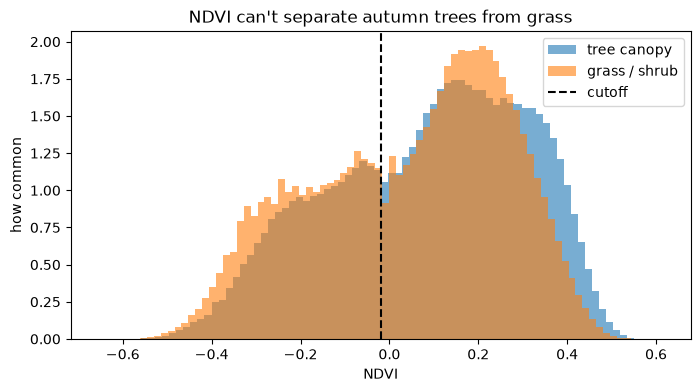

In [6]:
# NDVI distributions for tree and grass pixels.
ndvi_of_trees = test_ndvi[test_landcover == 1]
ndvi_of_grass = test_ndvi[test_landcover == 2]

plt.figure(figsize=(8, 4))
plt.hist(ndvi_of_trees, bins=80, alpha=0.6, density=True, label="tree canopy")
plt.hist(ndvi_of_grass, bins=80, alpha=0.6, density=True, label="grass / shrub")
plt.axvline(best_threshold, color="black", linestyle="--", label="cutoff")
plt.xlabel("NDVI")
plt.ylabel("how common")
plt.title("NDVI can't separate autumn trees from grass")
plt.legend()

plt.savefig(config.FIGURES_FOLDER / "02_ndvi_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

The overlapping data shows no NDVI threshold would be able to predict tree canopy from grass/shrub. Negative NDVI values are misleading and should be investigated.

In [7]:
class_names = {
    1: "tree canopy",
    2: "grass/shrub",
    3: "bare ground",
    4: "water",
    5: "building",
    6: "road",
    7: "other paved",
    8: "railroad",
}

# This breakdown applies only to false positives, since all misses are class 1.
false_positive_pixels = ndvi_prediction & (test_truth == 0)
classes_present, counts = np.unique(test_landcover[false_positive_pixels], return_counts=True)

print("False positives by land cover class:")
for i in range(len(classes_present)):
    class_number = classes_present[i]
    percent = 100 * counts[i] / counts.sum()
    print("  ", class_names[class_number], "=", round(percent, 1), "%")

False positives by land cover class:
   grass/shrub = 52.0 %
   bare ground = 0.6 %
   building = 12.2 %
   road = 8.7 %
   other paved = 26.4 %
   railroad = 0.1 %


In [8]:
missed_canopy = ~ndvi_prediction & (test_truth == 1)
found_canopy = ndvi_prediction & (test_truth == 1)

percent_missed = 100 * missed_canopy.sum() / (test_truth == 1).sum()

print("Canopy missed (%):", round(percent_missed, 1))
print("Median NDVI, canopy found: ", round(np.median(test_ndvi[found_canopy]), 3))
print("Median NDVI, canopy missed:", round(np.median(test_ndvi[missed_canopy]), 3))

Canopy missed (%): 32.4
Median NDVI, canopy found:  0.209
Median NDVI, canopy missed: -0.169
